# Model Training
## INX Future Inc — Employee Performance
### Made by - **Chinmay Shastry**
**Goal:** Train a classifier to predict employee performance rating.

## Step 1 — Load Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv('../../data/processed/employee_performance_processed.csv')
print("Shape:", df.shape)
print("Target distribution:")
print(df['PerformanceRating'].value_counts().sort_index())

Shape: (1200, 58)
Target distribution:
PerformanceRating
2    194
3    874
4    132
Name: count, dtype: int64


## Step 2 — Prepare Features & Target

In [2]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']
print(f"Features: {X.shape[1]}  |  Target classes: {sorted(y.unique())}")

Features: 57  |  Target classes: [2, 3, 4]


## Step 3 — Feature Importance Screening (Select Top 25)

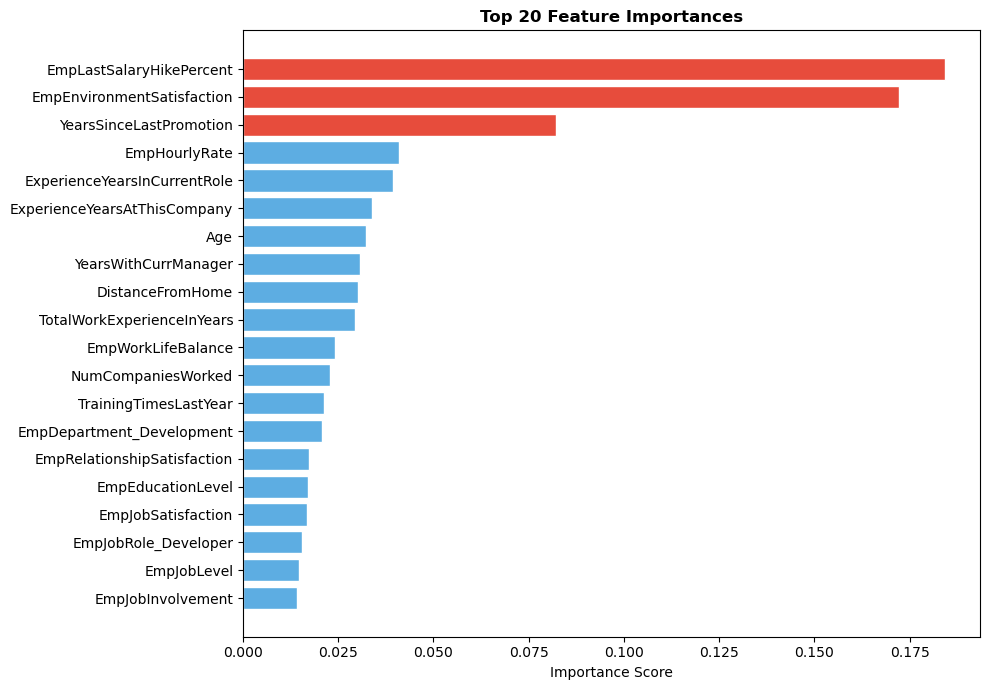


Top 3 Most Important Features:
  1. EmpLastSalaryHikePercent: 0.1843
  2. EmpEnvironmentSatisfaction: 0.1722
  3. YearsSinceLastPromotion: 0.0822


In [3]:
# Quick RF to find most important features
rf_screen = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_screen.fit(X, y)

feat_imp = pd.Series(rf_screen.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if i < 3 else '#5dade2' for i in range(20)]
plt.barh(feat_imp.head(20).index[::-1], feat_imp.head(20).values[::-1],
         color=colors[::-1], edgecolor='white')
plt.title('Top 20 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 Most Important Features:")
for i, (f, v) in enumerate(feat_imp.head(3).items(), 1):
    print(f"  {i}. {f}: {v:.4f}")

# Keep top 25 for modelling
selected = feat_imp.head(25).index.tolist()
X = X[selected]

## Step 4 — Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (960, 25)  |  Test: (240, 25)


## Step 5 — Handle Class Imbalance (Oversampling)

In [5]:
# Oversample minority classes to balance the training set
train_df = pd.concat([X_train, y_train], axis=1)
max_count = train_df['PerformanceRating'].value_counts().max()

balanced = pd.concat([
    resample(train_df[train_df['PerformanceRating'] == cls],
             replace=True, n_samples=max_count, random_state=42)
    for cls in train_df['PerformanceRating'].unique()
])

X_train_bal = balanced.drop(columns=['PerformanceRating'])
y_train_bal = balanced['PerformanceRating']

print("After balancing:")
print(y_train_bal.value_counts().sort_index())

After balancing:
PerformanceRating
2    699
3    699
4    699
Name: count, dtype: int64


## Step 6 — Scale Features

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)
print("Features scaled with StandardScaler")

Features scaled with StandardScaler


## Step 7 — Compare Multiple Models

In [7]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_score = cross_val_score(model, X_train_sc, y_train_bal, cv=cv, scoring='accuracy').mean()
    model.fit(X_train_sc, y_train_bal)
    test_acc = accuracy_score(y_test, model.predict(X_test_sc))
    results[name] = {'CV Accuracy': round(cv_score, 4), 'Test Accuracy': round(test_acc, 4)}
    print(f"{name:25s} | CV: {cv_score:.4f} | Test: {test_acc:.4f}")

results_df = pd.DataFrame(results).T
print("\nBest model:", results_df['Test Accuracy'].idxmax())

Logistic Regression       | CV: 0.8221 | Test: 0.7458
Random Forest             | CV: 0.9924 | Test: 0.9333
Gradient Boosting         | CV: 0.9876 | Test: 0.9083
SVM                       | CV: 0.9580 | Test: 0.7708

Best model: Random Forest


## Step 8 — Evaluate Best Model

In [8]:
# Random Forest is the best performer
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_sc)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low(2)','Good(3)','Excellent(4)']))

Accuracy : 0.9333
F1 Score : 0.9315

Classification Report:
              precision    recall  f1-score   support

      Low(2)       0.89      0.87      0.88        39
     Good(3)       0.94      0.98      0.96       175
Excellent(4)       0.95      0.73      0.83        26

    accuracy                           0.93       240
   macro avg       0.93      0.86      0.89       240
weighted avg       0.93      0.93      0.93       240



## Step 9 — Confusion Matrix

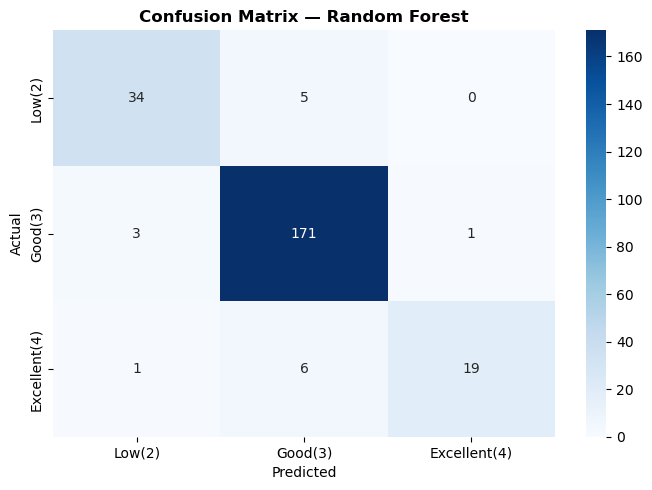

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low(2)','Good(3)','Excellent(4)'],
            yticklabels=['Low(2)','Good(3)','Excellent(4)'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 10 — Save Model

In [10]:
artifacts = {
    'model'            : best_model,
    'scaler'           : scaler,
    'selected_features': selected,
    'top3_features'    : feat_imp.head(3).index.tolist(),
    'feature_importances': feat_imp.to_dict()
}

with open('../../data/processed/trained_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Model saved!")
print("Top 3 features:", artifacts['top3_features'])

Model saved!
Top 3 features: ['EmpLastSalaryHikePercent', 'EmpEnvironmentSatisfaction', 'YearsSinceLastPromotion']
